# T2: Plot the prior distribution of the two classes

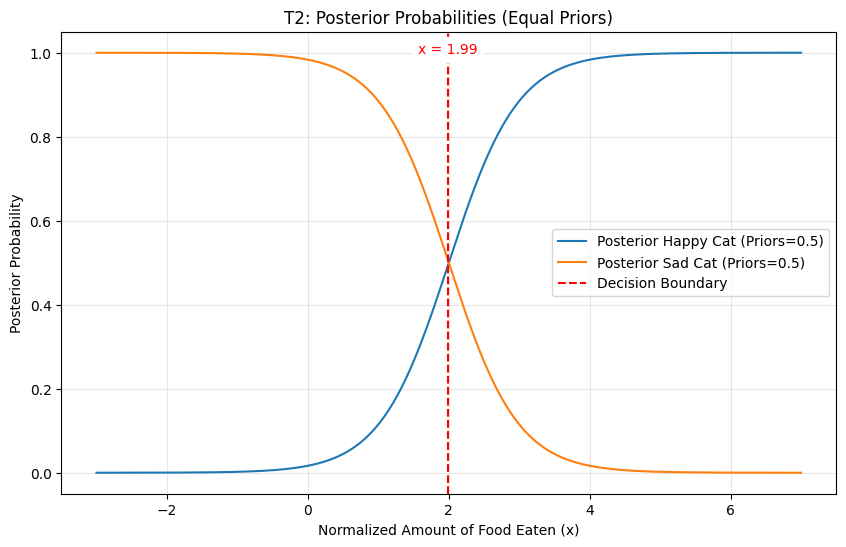

T2 Decision Boundary: x = 1.9900


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# Parameters 
# ==========================================

# Class w1: Happy Cat (Assuming from previous context or generic example parameters)
mu_1 = 4.0      
sigma_1 = 1.4   

# Class w2: Sad Cat
mu_2 = 0.0      
sigma_2 = 1.4   

# T2 Assumption: Equal Priors
prior_1_t2 = 0.5   
prior_2_t2 = 0.5   

# 1. Define Range of x (Normalized Food Eaten)
x_range = np.linspace(-3, 7, 500)

# 2. Calculate Likelihoods P(x|w)
likelihood_1 = norm.pdf(x_range, mu_1, sigma_1) # Happy Cat
likelihood_2 = norm.pdf(x_range, mu_2, sigma_2) # Sad Cat

# 3. Calculate Evidence P(x)
evidence_t2 = (likelihood_1 * prior_1_t2) + (likelihood_2 * prior_2_t2)

# 4. Calculate Posteriors P(w|x)
posterior_1_t2 = (likelihood_1 * prior_1_t2) / evidence_t2
posterior_2_t2 = (likelihood_2 * prior_2_t2) / evidence_t2

# 5. Find Decision Boundary (where posteriors intersect)
idx_t2 = np.argwhere(np.diff(np.sign(posterior_1_t2 - posterior_2_t2))).flatten()
decision_x_t2 = x_range[idx_t2][0]

# 6. Plot
plt.figure(figsize=(10, 6))
plt.plot(x_range, posterior_1_t2, label=f'Posterior Happy Cat (Priors={prior_1_t2})', color='tab:blue')
plt.plot(x_range, posterior_2_t2, label=f'Posterior Sad Cat (Priors={prior_2_t2})', color='tab:orange')
plt.axvline(x=decision_x_t2, color='red', linestyle='--', label='Decision Boundary')

plt.title('T2: Posterior Probabilities (Equal Priors)')
plt.xlabel('Normalized Amount of Food Eaten (x)')
plt.ylabel('Posterior Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.text(decision_x_t2, plt.ylim()[1]*0.95, f'x = {decision_x_t2:.2f}', color='red', ha='center', backgroundcolor='white')
plt.show()

print(f"T2 Decision Boundary: x = {decision_x_t2:.4f}")

# T3: Determine the decision boundary with new Prior
What happen to the decision boundary if the cat is happy with a prior of 0.75?

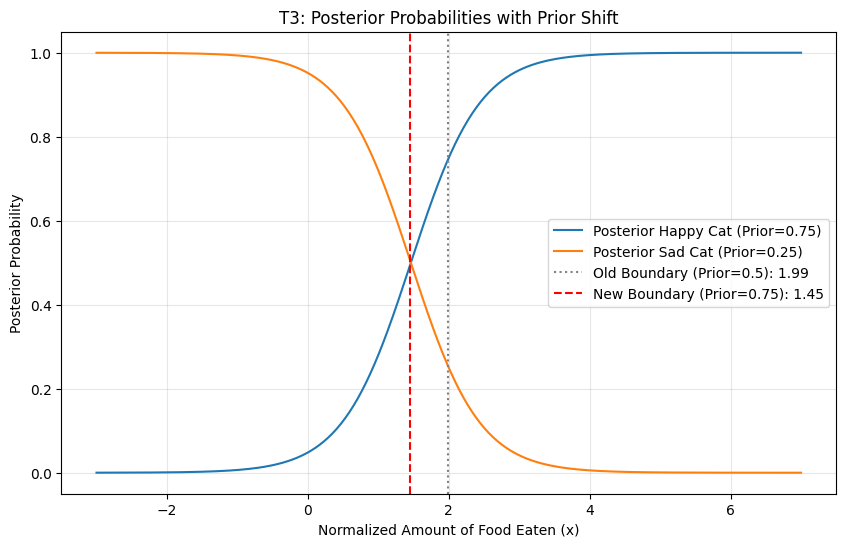

T2 Decision Boundary (Prior=0.5): x = 1.9900
T3 Decision Boundary (Prior=0.75): x = 1.4489
Observation: The decision boundary shifted to the LEFT, making the 'Happy Cat' region larger.


In [12]:
# T3 Parameters: Happy Cat Prior = 0.75
prior_1_t3 = 0.75
prior_2_t3 = 0.25  # (1 - 0.75)

# 1. Calculate Evidence P(x) with NEW priors
evidence_t3 = (likelihood_1 * prior_1_t3) + (likelihood_2 * prior_2_t3)

# 2. Calculate Posteriors P(w|x)
posterior_1_t3 = (likelihood_1 * prior_1_t3) / evidence_t3
posterior_2_t3 = (likelihood_2 * prior_2_t3) / evidence_t3

# 3. Find Decision Boundary
idx_t3 = np.argwhere(np.diff(np.sign(posterior_1_t3 - posterior_2_t3))).flatten()
decision_x_t3 = x_range[idx_t3][0]

# 4. Plot both T2 and T3 boundaries for comparison
plt.figure(figsize=(10, 6))
plt.plot(x_range, posterior_1_t3, label=f'Posterior Happy Cat (Prior={prior_1_t3})', color='tab:blue')
plt.plot(x_range, posterior_2_t3, label=f'Posterior Sad Cat (Prior={prior_2_t3})', color='tab:orange')

# Plot boundaries
plt.axvline(x=decision_x_t2, color='gray', linestyle=':', label=f'Old Boundary (Prior=0.5): {decision_x_t2:.2f}')
plt.axvline(x=decision_x_t3, color='red', linestyle='--', label=f'New Boundary (Prior=0.75): {decision_x_t3:.2f}')

plt.title('T3: Posterior Probabilities with Prior Shift')
plt.xlabel('Normalized Amount of Food Eaten (x)')
plt.ylabel('Posterior Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"T2 Decision Boundary (Prior=0.5): x = {decision_x_t2:.4f}")
print(f"T3 Decision Boundary (Prior=0.75): x = {decision_x_t3:.4f}")
print("Observation: The decision boundary shifted to the LEFT, making the 'Happy Cat' region larger.")